In [257]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
import warnings

# Warnungen unterdrücken für eine saubere Demo
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Nutze Gerät: {device}")

Nutze Gerät: cpu


In [258]:
model_name = "nlpconnect/vit-gpt2-image-captioning"
processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)

# WICHTIG: Gradienten für den Rückwärtsweg aktivieren
model.eval()
for param in model.parameters():
    param.requires_grad = True

print("Modell erfolgreich geladen!")

Loading weights: 100%|██████████| 445/445 [00:00<00:00, 41822.74it/s]
[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modell erfolgreich geladen!


In [259]:
activations = None
gradients = None

# Vorwärts-Hook
def forward_hook(module, input, output):
    global activations
    activations = output[0] if isinstance(output, tuple) else output

# Rückwärts-Hook
def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0] if isinstance(grad_output, tuple) else grad_output

# Alle 12 Transformer-Blöcke (ViTLayer) des Encoders in eine Liste laden
vit_layers = [module for module in model.encoder.modules() if module.__class__.__name__ == "ViTLayer"]
print(f"Anzahl gefundener ViT-Layer: {len(vit_layers)}")

# =========================================================================
# EXPERIMENTIER-BEREICH FÜR DEINE VORLESUNG
# =========================================================================
# Index 11 ist der allerletzte Layer (der unter den Hintergrund-Artefakten leidet).
# Ändere diesen Wert auf 6, 7 oder 8, um viel lokalere Heatmaps zu bekommen!
LAYER_INDEX = 11

target_layer = vit_layers[LAYER_INDEX]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

print(f"Sensoren (Hooks) erfolgreich an ViT-Layer [Index {LAYER_INDEX}] angebracht!")

Anzahl gefundener ViT-Layer: 12
Sensoren (Hooks) erfolgreich an ViT-Layer [Index 11] angebracht!


In [260]:
def generate_caption_gradcam(image_path, target_word):
    # 1. Bild verarbeiten
    original_image = Image.open(image_path).convert("RGB")
    image = original_image.resize((224, 224))
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
    
    # 2. Satz generieren
    output_ids = model.generate(pixel_values, max_length=16)
    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    print(f"\nGenerierter Satz: '{generated_text}'")
    
    # 3. Den richtigen Token finden (DER NEUE AKKUMULATOR-FIX)
    word_index = -1
    target_token_id = -1
    
    current_string = ""
    for i, token_id in enumerate(output_ids[0]):
        # Wir hängen jedes generierte Token an unseren String an
        token_str = tokenizer.decode([token_id])
        current_string += token_str
        
        # Sobald unser gesuchtes Wort komplett im Text aufgetaucht ist...
        if target_word.lower() in current_string.lower():
            word_index = i
            target_token_id = token_id
            print(f"-> Treffer! Wort '{target_word}' wurde durch das Token '{token_str}' an Position {i} komplettiert.")
            break
            
    if word_index == -1:
        print(f"ABBRUCH: Das Wort '{target_word}' ist im Satz nicht enthalten.")
        return image, None, generated_text
        
    # 4. Den Score abgreifen (Die Logit-Shift-Logik: word_index - 1)
    model.zero_grad()
    outputs = model(pixel_values=pixel_values, decoder_input_ids=output_ids)
    target_score = outputs.logits[0, word_index - 1, target_token_id]
    
    # 5. BACKPROPAGATION
    target_score.backward(retain_graph=True)
    
    # 6. Grad-CAM Mathematik
    global activations, gradients
    
    act = activations[0, 1:, :] 
    grad = gradients[0, 1:, :]  
    
    grid_size = int(np.sqrt(act.shape[0]))
    act = act.reshape(grid_size, grid_size, -1).permute(2, 0, 1)   
    grad = grad.reshape(grid_size, grid_size, -1).permute(2, 0, 1) 
    
    pooled_gradients = torch.mean(grad, dim=[1, 2]) 
    
    for i in range(act.shape[0]):
        act[i, :, :] *= pooled_gradients[i]
        
    heatmap = torch.sum(act, dim=0).squeeze().detach().cpu().numpy()
    heatmap = np.maximum(heatmap, 0) 
    
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)
    
    return image, heatmap, generated_text


Generierter Satz: 'a woman in a white shirt and black shorts playing soccer '
-> Treffer! Wort 'woman' wurde durch das Token ' woman' an Position 2 komplettiert.


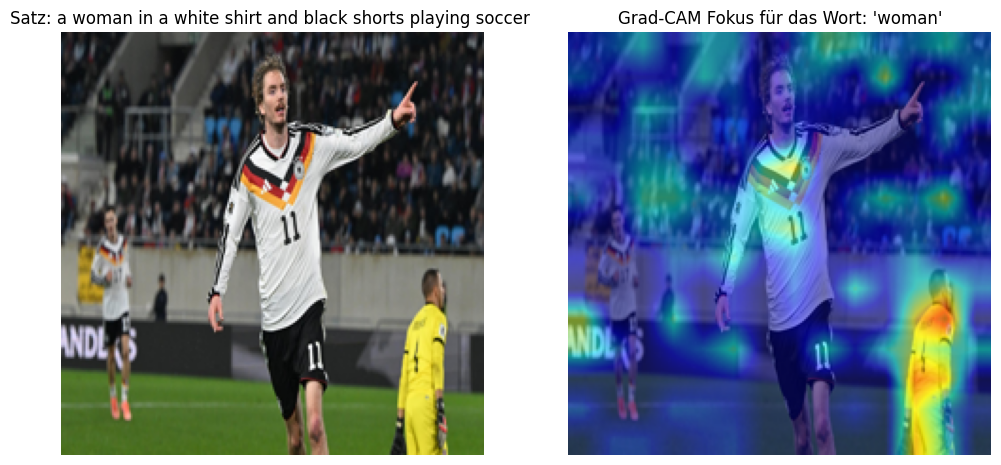

In [261]:
# HIER BILD UND WORT EINTRAGEN
# Tipp: Führe die Zelle zuerst mit target_word="test" aus, 
# schau dir an welchen englischen Satz das Modell generiert,
# und trage DANN eines der Wörter hier ein!
image_path = "test_images/woltemessi.png" 
target_word = "woman" # Ersetze dies durch ein Wort aus dem generierten Satz!

img_pil, heatmap, text = generate_caption_gradcam(image_path, target_word)

if heatmap is not None:
    # Mischen (nutze img_pil, das jetzt quadratisch ist)
    img_cv = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    superimposed_img = heatmap_color * 0.5 + img_cv * 0.5
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    # Plotten
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_pil)
    plt.title(f"Satz: {text}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM Fokus für das Wort: '{target_word}'")
    plt.axis('off')
    plt.show()